# **Heart disease dataset**

## METHOD 1. **Logistic Regression** with balanced class weights


=== Logistic Regression Evaluation ===
Accuracy     : 0.6774
Precision    : 0.2435
Recall       : 0.7685
Specificity  : 0.6646
F1 Score     : 0.3698
ROC AUC      : 0.7847

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.66      0.78     56354
           1       0.24      0.77      0.37      7917

    accuracy                           0.68     64271
   macro avg       0.60      0.72      0.58     64271
weighted avg       0.87      0.68      0.73     64271


=== Confusion Matrix ===
True Negatives (TN): 37451
False Positives (FP): 18903
False Negatives (FN): 1833
True Positives (TP): 6084


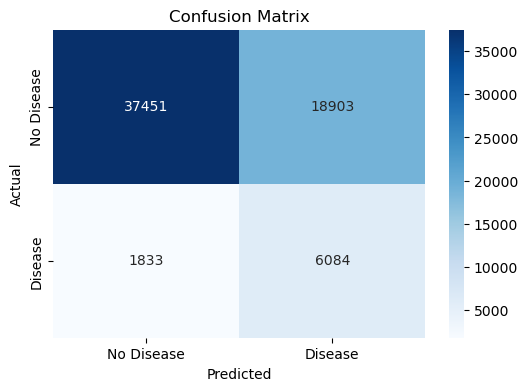


Top Contributing Features (Logistic Coefficients):
                        Feature  Coefficient
14  AgeCategory_Age 80 or older     0.910630
12     AgeCategory_Age 70 to 74     0.791640
13     AgeCategory_Age 75 to 79     0.776268
11     AgeCategory_Age 65 to 69     0.756017
10     AgeCategory_Age 60 to 64     0.628837
9      AgeCategory_Age 55 to 59     0.595965
8      AgeCategory_Age 50 to 54     0.388864
15                     Sex_Male     0.279540
22    SmokerStatus_Never smoked    -0.276319
7      AgeCategory_Age 45 to 49     0.274191


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

heart_df = pd.read_csv("heart_final.csv")

# Define Features and Target
X = heart_df.drop(columns=['HeartDisease'])
y = heart_df['HeartDisease']

# Split into Train/Test Sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Compute Specificity
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Print Results
print("\n=== Logistic Regression Evaluation ===")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Print Confusion Matrix
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': logreg.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop Contributing Features (Logistic Coefficients):")
print(coef_df.head(10))


## METHOD 1'. **Logistic Regression** without balanced class weights 


=== Logistic Regression Evaluation ===
Accuracy     : 0.8768
Precision    : 0.4981
Recall       : 0.0494
Specificity  : 0.9930
F1 Score     : 0.0899
ROC AUC      : 0.7848

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93     56354
           1       0.50      0.05      0.09      7917

    accuracy                           0.88     64271
   macro avg       0.69      0.52      0.51     64271
weighted avg       0.83      0.88      0.83     64271



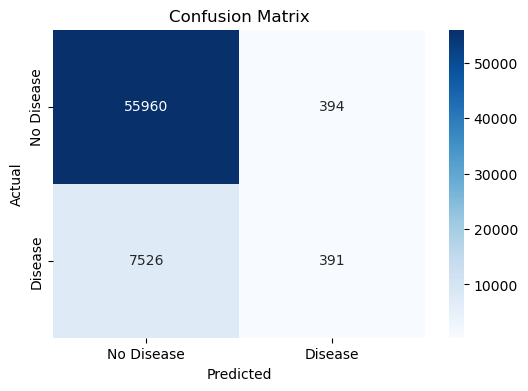


Top Contributing Features (Logistic Coefficients):
                        Feature  Coefficient
14  AgeCategory_Age 80 or older     0.903960
12     AgeCategory_Age 70 to 74     0.795948
13     AgeCategory_Age 75 to 79     0.774454
11     AgeCategory_Age 65 to 69     0.763332
10     AgeCategory_Age 60 to 64     0.635350
9      AgeCategory_Age 55 to 59     0.605156
8      AgeCategory_Age 50 to 54     0.400961
15                     Sex_Male     0.285252
7      AgeCategory_Age 45 to 49     0.280279
22    SmokerStatus_Never smoked    -0.257099


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

heart_df = pd.read_csv("heart_final.csv")

# Define Features and Target
X = heart_df.drop(columns=['HeartDisease'])
y = heart_df['HeartDisease']

# Split into Train/Test Sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = logreg.predict(X_test_scaled)
y_prob = logreg.predict_proba(X_test_scaled)[:, 1]

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

# Compute Specificity
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# Print Results
print("\n=== Logistic Regression Evaluation ===")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance (Coefficients)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': logreg.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop Contributing Features (Logistic Coefficients):")
print(coef_df.head(10))


## METHOD 2. **Decision Tree**

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix)

heart_df = pd.read_csv("heart_final_label.csv") 

# Separate features and target
X = heart_df.drop(columns='HeartDisease')
y = heart_df['HeartDisease']

# Train-test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train Decision Tree with class_weight='balanced'
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8)
dt.fit(X_train_scaled, y_train)

# Predictions
y_pred = dt.predict(X_test_scaled)
y_proba = dt.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
spec = confusion_matrix(y_test, y_pred)[0, 0] / sum(confusion_matrix(y_test, y_pred)[0])
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

# Print Evaluation
print("=== Decision Tree Evaluation (Heart Disease) ===")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print("              Predicted No   Predicted Yes")
print(f"Actual No     {tn:>10}       {fp:>10}")
print(f"Actual Yes    {fn:>10}       {tp:>10}")

# Feature Importances
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nTop Contributing Features (Decision Tree Importances):")
print(feature_importance.head(10))


=== Decision Tree Evaluation (Heart Disease) ===
Accuracy     : 0.6652
Precision    : 0.2363
Recall       : 0.7697
Specificity  : 0.6505
F1 Score     : 0.3616
ROC AUC      : 0.7772

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.65      0.77     56354
           1       0.24      0.77      0.36      7917

    accuracy                           0.67     64271
   macro avg       0.59      0.71      0.57     64271
weighted avg       0.86      0.67      0.72     64271


=== Confusion Matrix ===
True Negatives (TN): 36661
False Positives (FP): 19693
False Negatives (FN): 1823
True Positives (TP): 6094

Matrix Format:
              Predicted No   Predicted Yes
Actual No          36661            19693
Actual Yes          1823             6094

Top Contributing Features (Decision Tree Importances):
               Feature  Importance
0          AgeCategory    0.720284
8          HadDiabetes    0.081130
10        HadArthritis    0.06

## METHOD 3. **Random Forest**

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

heart_df = pd.read_csv("heart_final.csv")

# Define Features and Target
X = heart_df.drop(columns=['HeartDisease'])
y = heart_df['HeartDisease']

# Split into Train/Test Sets (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Numeric Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model with class_weight='balanced' to handle class imbalance
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
specificity = confusion_matrix(y_test, y_pred)[0,0] / (confusion_matrix(y_test, y_pred)[0,0] + confusion_matrix(y_test, y_pred)[0,1])
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Display metrics
print("=== Random Forest Evaluation (Heart Disease) ===")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature Importances
importances = rf.feature_importances_
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\nTop Contributing Features (Random Forest Importances):")
print(feature_imp_df.head(10))


=== Random Forest Evaluation (Heart Disease) ===
Accuracy     : 0.8381
Precision    : 0.2318
Recall       : 0.1359
Specificity  : 0.9367
F1 Score     : 0.1714
ROC AUC      : 0.6963

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91     56354
           1       0.23      0.14      0.17      7917

    accuracy                           0.84     64271
   macro avg       0.56      0.54      0.54     64271
weighted avg       0.80      0.84      0.82     64271


=== Confusion Matrix ===
True Negatives (TN): 52788
False Positives (FP): 3566
False Negatives (FN): 6841
True Positives (TP): 1076

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           52788          3566
Actual Yes          6841           1076

Top Contributing Features (Random Forest Importances):
                        Feature  Importance
0                           BMI    0.404357
1                    SleepHours    0.106973
2 

## METHOD 4. **LightGBM** (without SMOTE) threshold = 0.2 is optimal

In [14]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

# Load data
heart_df = pd.read_csv("heart_final.csv")

# Define features and target
X = heart_df.drop(columns=['HeartDisease'])
y = heart_df['HeartDisease']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Calculate class imbalance weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

# Initialize LightGBM classifier
model = lgb.LGBMClassifier(objective='binary',
                           boosting_type='gbdt',
                           learning_rate=0.05,
                           num_leaves=31,
                           n_estimators=100,
                           scale_pos_weight=scale_pos_weight,
                           random_state=42)

# Train model
model.fit(X_train_scaled, y_train)

# Predict probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# ===== Threshold Tuning =====
threshold = 0.2 
y_pred = (y_pred_proba >= threshold).astype(int)

# === Evaluation Metrics ===
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred)
specificity = confusion_matrix(y_test, y_pred)[0, 0] / (confusion_matrix(y_test, y_pred)[0, :].sum())
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== LightGBM Evaluation (Heart Disease) ===")
print(f"Threshold    : {threshold}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc_auc:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature importances
importances = model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

print("\nTop Contributing Features (LightGBM Importances):")
print(feature_imp_df.head(10))



[LightGBM] [Info] Number of positive: 31670, number of negative: 225411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 440
[LightGBM] [Info] Number of data points in the train set: 257081, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.123191 -> initscore=-1.962556
[LightGBM] [Info] Start training from score -1.962556
=== LightGBM Evaluation (Heart Disease) ===
Threshold    : 0.2
Accuracy     : 0.4211
Precision    : 0.1711
Recall       : 0.9624
Specificity  : 0.3451
F1 Score     : 0.2906
ROC AUC      : 0.7883

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.35      0.51     56354
           1       0.17      0.96      0.29      7917

    accuracy                           0.42     64271
   m

# METHOD 4'. **LightGBM with SMOTE** Threshold Tuning (0.10 – 0.81) + Visualization

[LightGBM] [Info] Number of positive: 225411, number of negative: 225411
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3780
[LightGBM] [Info] Number of data points in the train set: 450822, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[32]	valid_0's auc: 0.772876	valid_0's binary_logloss: 0.527274

=== Best Threshold Based on F1 Score ===
Threshold      0.530000
Accuracy       0.747662
Precision      0.267908
Recall         0.605153
Specificity    0.767683
F1 Score       0.371395
Name: 43, dtype: float64


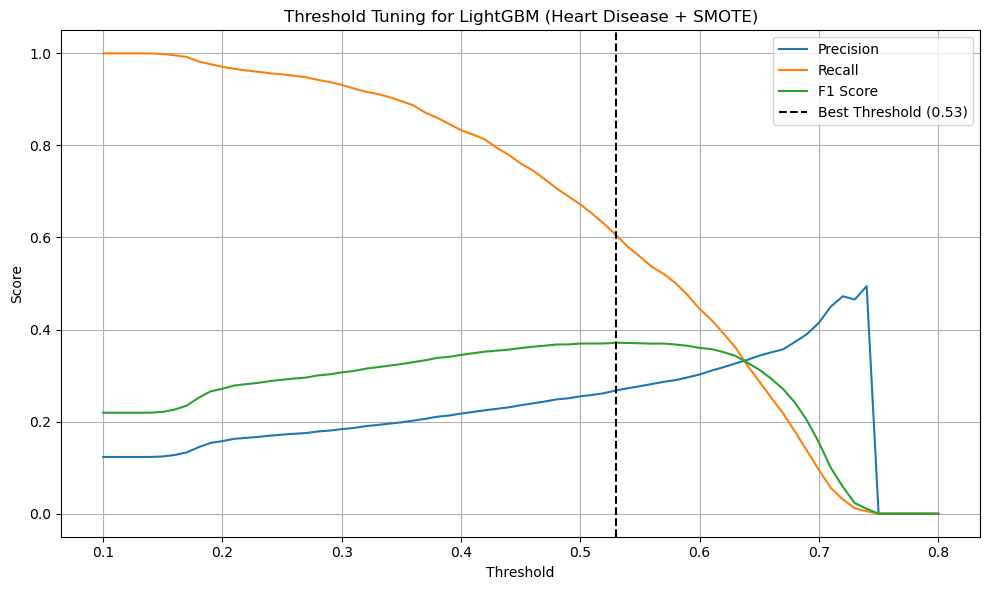


=== LightGBM Final Evaluation (Heart Disease + SMOTE) ===
Threshold    : 0.53
Accuracy     : 0.7477
Precision    : 0.2679
Recall       : 0.6052
Specificity  : 0.7677
F1 Score     : 0.3714
ROC AUC      : 0.7729

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.77      0.84     56354
           1       0.27      0.61      0.37      7917

    accuracy                           0.75     64271
   macro avg       0.60      0.69      0.61     64271
weighted avg       0.85      0.75      0.78     64271


=== Confusion Matrix ===
True Negatives (TN): 43262
False Positives (FP): 13092
False Negatives (FN): 3126
True Positives (TP): 4791

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           43262          13092
Actual Yes          3126           4791

Top Contributing Features (LightGBM Importances):
                                           Feature  Importance
15                                        Se

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

heart_df = pd.read_csv("heart_final.csv")

# Split features and target
X = heart_df.drop(columns=['HeartDisease'])
y = heart_df['HeartDisease']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to balance training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

# Train LightGBM model
model = lgb.LGBMClassifier(objective='binary', boosting_type='gbdt', is_unbalance=False, learning_rate=0.05,
    num_leaves=31, n_estimators=100, random_state=42)

model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_test_scaled, y_test)],
    eval_metric='auc', callbacks=[lgb.early_stopping(stopping_rounds=10)])

# Predict probabilities
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate thresholds
thresholds = np.arange(0.10, 0.81, 0.01)
results = []

for thresh in thresholds:
    y_pred = (y_proba >= thresh).astype(int)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp)
    results.append({'Threshold': thresh, 'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall, 'Specificity': specificity, 'F1 Score': f1})

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Best threshold
best_row = results_df.loc[results_df['F1 Score'].idxmax()]
print("\n=== Best Threshold Based on F1 Score ===")
print(best_row)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score')
plt.axvline(best_row['Threshold'], color='black', linestyle='--', label=f"Best Threshold ({best_row['Threshold']:.2f})")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for LightGBM (Heart Disease + SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Final evaluation
final_threshold = best_row['Threshold']
y_pred_final = (y_proba >= final_threshold).astype(int)

# Metrics
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, zero_division=0)
rec = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
auc = roc_auc_score(y_test, y_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
spec = tn / (tn + fp)

print("\n=== LightGBM Final Evaluation (Heart Disease + SMOTE) ===")
print(f"Threshold    : {final_threshold:.2f}")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature importances
feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\nTop Contributing Features (LightGBM Importances):")
print(feature_imp_df.head(10))


In [6]:
#!pip install xgboost

## METHOD 5. **XGBoost** + SMOTE (to balance classes)


=== Best Threshold Based on F1 Score ===
Threshold      0.180000
Accuracy       0.770550
Precision      0.289794
Recall         0.594670
Specificity    0.795259
F1 Score       0.389687
Name: 8, dtype: float64


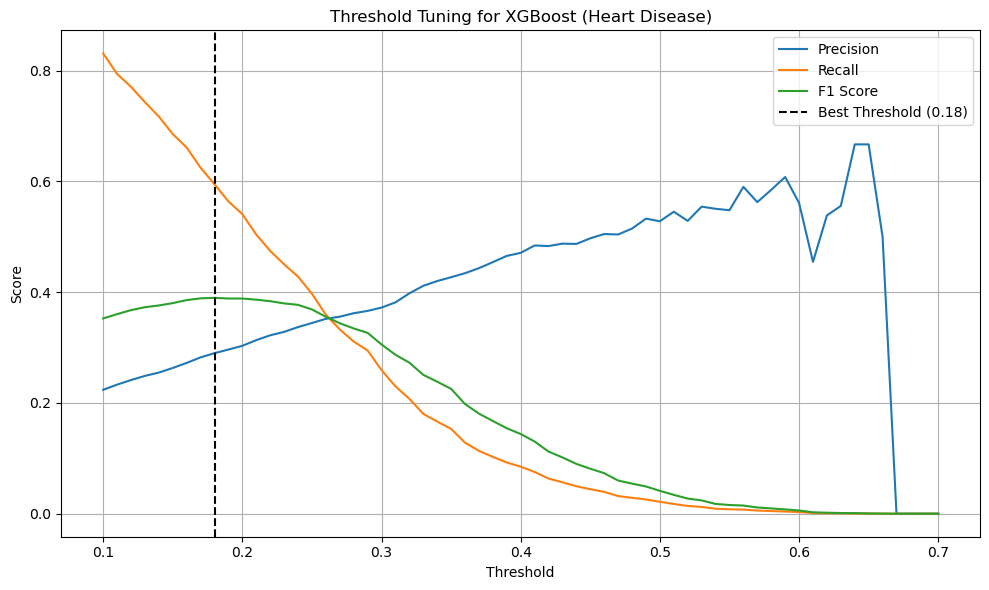


=== XGBoost Final Evaluation (Heart Disease) ===
Threshold    : 0.18
Accuracy     : 0.7705
Precision    : 0.2898
Recall       : 0.5947
Specificity  : 0.7953
F1 Score     : 0.3897
ROC AUC      : 0.7829

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     56354
           1       0.29      0.59      0.39      7917

    accuracy                           0.77     64271
   macro avg       0.61      0.69      0.62     64271
weighted avg       0.85      0.77      0.80     64271


=== Confusion Matrix ===
True Negatives (TN): 44816
False Positives (FP): 11538
False Negatives (FN): 3209
True Positives (TP): 4708

Matrix Format:
                    Predicted No   Predicted Yes
Actual No           44816          11538
Actual Yes          3209           4708

Top Contributing Features (XGBoost Importances):
HadArthritis_Yes               0.194024
HadDiabetes_Yes                0.152706
AgeCategory_Age 80 or older    0.0898

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

df = pd.read_csv("heart_final.csv")

# Define features and target
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Standardize numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE to training data
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_scaled, y_train)

# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='auc',
                              learning_rate=0.05, n_estimators=100,
                              max_depth=5, scale_pos_weight=1,
                              random_state=42)


# Train the model
xgb_model.fit(X_train_scaled, y_train)

# Predict probabilities
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
thresholds = np.arange(0.1, 0.71, 0.01)
results = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    spec = confusion_matrix(y_test, y_pred)[0, 0] / sum(confusion_matrix(y_test, y_pred)[0])
    results.append({'Threshold': t, 'Accuracy': acc, 'Precision': prec,
                    'Recall': rec, 'Specificity': spec, 'F1 Score': f1})

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Best threshold by F1
best_row = results_df.loc[results_df['F1 Score'].idxmax()]
print("\n=== Best Threshold Based on F1 Score ===")
print(best_row)

# Plot threshold tuning
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score')
plt.axvline(best_row['Threshold'], color='black', linestyle='--', label=f"Best Threshold ({best_row['Threshold']:.2f})")
plt.title("Threshold Tuning for XGBoost (Heart Disease)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Final evaluation with best threshold
final_thresh = best_row['Threshold']
y_final_pred = (y_probs >= final_thresh).astype(int)

# Metrics
acc = accuracy_score(y_test, y_final_pred)
prec = precision_score(y_test, y_final_pred, zero_division=0)
rec = recall_score(y_test, y_final_pred)
spec = confusion_matrix(y_test, y_final_pred)[0, 0] / sum(confusion_matrix(y_test, y_final_pred)[0])
f1 = f1_score(y_test, y_final_pred)
roc_auc = roc_auc_score(y_test, y_probs)

print("\n=== XGBoost Final Evaluation (Heart Disease) ===")
print(f"Threshold    : {final_thresh:.2f}")
print(f"Accuracy     : {acc:.4f}")
print(f"Precision    : {prec:.4f}")
print(f"Recall       : {rec:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"ROC AUC      : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_final_pred))

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_final_pred).ravel()
print("\n=== Confusion Matrix ===")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print("\nMatrix Format:")
print(f"{'':<20}{'Predicted No':<15}{'Predicted Yes'}")
print(f"{'Actual No':<20}{tn:<15}{fp}")
print(f"{'Actual Yes':<20}{fn:<15}{tp}")

# Feature Importances
feat_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print("\nTop Contributing Features (XGBoost Importances):")
print(feat_imp.head(10))


## Method 5'. **XGBoost (ROC and PR Curve)**

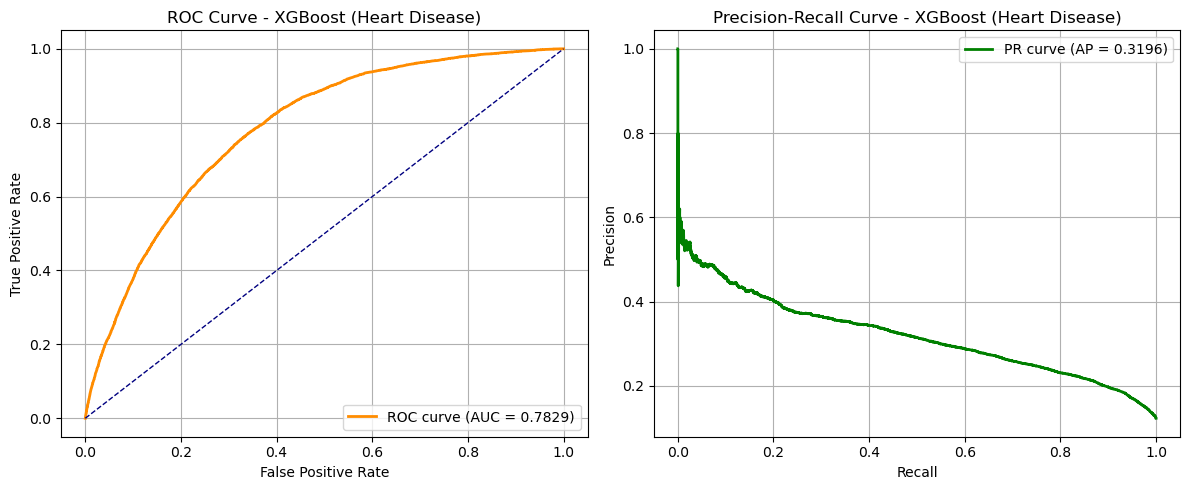

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Heart Disease)')
plt.legend(loc="lower right")
plt.grid(True)

# Plot Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost (Heart Disease)')
plt.legend(loc="upper right")
plt.grid(True)

plt.tight_layout()
plt.show()
